# 09 — Placement Recalibration (Roadmap Step 4)

**Diagnostic and validation only.** This notebook does **not** touch the
750-compound blind test set and does **not** retrain any model. Every input
below is an already-existing out-of-fold (OOF) prediction on disk from
`05_cv_comparison`, `06_outlier_check`, `07_weighting_tuning`, and
`08_ensemble_selection` — this notebook only pools, diagnoses, and (from
Section 3 onward, once Section 2's threshold is confirmed) nested-CV-validates
a post-hoc linear recalibration of those predictions. The frozen recalibration
parameters this notebook produces are for a later, separate retrain-and-predict
step to consume — nothing here is applied to the blind test set directly.

## Background: the R² placement decomposition

Raw R² decomposes as

$$R^2 = 2\rho k - k^2 - b^2$$

where:
- $\rho$ = Pearson correlation between raw predicted and true pIC50 (pooled OOF),
- $k = \sigma_{\text{pred}} / \sigma_{\text{true}}$ — the spread ratio,
- $b = (\bar y_{\text{pred}} - \bar y_{\text{true}}) / \sigma_{\text{true}}$ — the standardized bias.

The algebra is a direct five-line expansion of $R^2 = 1 - SS_{res}/SS_{tot}$ via
centered variables — worked out in the **Appendix** cell at the end of this
notebook. The applied idea of using this decomposition to triage "is this
isoform's R² gap fixable by a cheap linear placement correction, or is it a
correlation-limited model problem no simple rescale/shift can fix" is **not**
original to this project — it follows the SuperCowPowers/`workbench`
"placement correction" write-up for this same OpenADMET CYP challenge.

> **Citation status — pending user confirmation, not yet finalized.** The
> project instructions asked to "confirm exact citation from Zotero" for this
> idea before it's stated as fact. While building this notebook, a candidate
> source was located and verified to actually exist (see the chat message
> alongside this notebook for the verification trail):
> **SuperCowPowers/briford, "placement correction" write-up,
> <https://supercowpowers.github.io/workbench/blogs/cyp_challenge/>**, code at
> <https://github.com/SuperCowPowers/workbench>. This is used as a placeholder
> citation below pending the user confirming it matches their own Zotero
> record (or supplying the correct one).

## Prediction source per isoform

Read directly from `outputs/08_ensemble_selection/step3_summary.csv` at
runtime below (not hardcoded) — for each isoform, whichever source won
Roadmap Step 3:

- **CYP1A2, CYP2D6, CYP3A4** — the step-3 winning combo is a simple-average
  ensemble. Its OOF prediction is reconstructed here per (repeat, fold) by
  reusing `08_ensemble_selection`'s own `load_model_oof` / `build_pool_wide`
  helpers (copied below, consistent with notebook 08's actual implementation)
  on that combo's member models, sourced from wherever notebook 08 loaded them
  (05/06/07 prediction directories, per the pool definitions notebook 08
  established for each isoform).
- **CYP2C9** — `single_best_label` is `chemprop_chemeleoninit` (05), no
  ensemble was tested for this isoform in step 3. Its OOF predictions are
  loaded directly, no averaging.


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))  # so `from src... import ...` works regardless of cwd

import importlib.metadata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score

print(f"python: {sys.version.split()[0]}")
for pkg in ["numpy", "pandas", "scipy", "scikit-learn", "matplotlib"]:
    print(f"{pkg}: {importlib.metadata.version(pkg)}")

OUT05 = REPO_ROOT / "outputs" / "05_cv_comparison"
OUT06 = REPO_ROOT / "outputs" / "06_outlier_check"
OUT07 = REPO_ROOT / "outputs" / "07_weighting_tuning"
OUT08 = REPO_ROOT / "outputs" / "08_ensemble_selection"
OUT = REPO_ROOT / "outputs" / "09_placement_recalibration"
FIG_OUT = OUT / "figures"
FIG_OUT.mkdir(parents=True, exist_ok=True)

CURATED_PATH = REPO_ROOT / "data" / "processed" / "train_inhibition_curated.csv"
curated = pd.read_csv(CURATED_PATH)
print(f"curated: {curated.shape}")

PRED_DIRS = {"05": OUT05 / "predictions", "06": OUT06 / "predictions", "07": OUT07 / "predictions"}
SCORE_DIRS = {"05": OUT05 / "scores", "06": OUT06 / "scores", "07": OUT07 / "scores"}

N_REPEATS, N_FOLDS = 5, 5
ISOFORMS = ["CYP1A2", "CYP2C9", "CYP2D6", "CYP3A4"]  # matches config.REGRESSION_ENDPOINTS order

python: 3.11.13
numpy: 1.26.4
pandas: 2.3.3
scipy: 1.17.1
scikit-learn: 1.9.0
matplotlib: 3.11.1
curated: (4905, 20)


## Shared helper functions (reused from 08)

`load_model_oof` and `build_pool_wide` are copied verbatim from
`08_ensemble_selection.ipynb`'s own "Shared helper functions" cell — per the
project instructions, reused rather than reimplemented. `load_existing_fold_scores`
and `point_estimate` are likewise copied from 08, used below only to load
each source's *already-computed* per-fold R² (the "observed R²" sanity-check
target in Section 1) — no bootstrap is re-run anywhere in this notebook.

In [2]:
def load_model_oof(source: str, tag: str, isoform_col: str) -> pd.DataFrame:
    '''Load one model's 25 (repeat, fold) OOF prediction files for one isoform
    column, concatenated with repeat/fold columns attached. Copied verbatim
    from 08_ensemble_selection.ipynb.'''
    rows = []
    for repeat in range(N_REPEATS):
        for fold in range(N_FOLDS):
            path = PRED_DIRS[source] / f"{tag}__repeat{repeat}_fold{fold}.csv"
            df = pd.read_csv(path, usecols=["Molecule_Name", "inchikey", isoform_col])
            df["repeat"], df["fold"] = repeat, fold
            rows.append(df)
    return pd.concat(rows, ignore_index=True)


def build_pool_wide(pool_specs: dict, isoform_col: str) -> pd.DataFrame:
    '''One row per (repeat, fold, inchikey), one column per pool member's OOF
    prediction for `isoform_col`, inner-joined on (repeat, fold, inchikey).
    Copied verbatim from 08_ensemble_selection.ipynb.'''
    wide, n_first = None, None
    for name, (source, tag) in pool_specs.items():
        long_df = load_model_oof(source, tag, isoform_col).rename(columns={isoform_col: name})
        print(f"  loaded {name} ({source}/{tag}): {len(long_df)} rows ({N_REPEATS * N_FOLDS} folds)")
        if wide is None:
            wide = long_df[["repeat", "fold", "inchikey", "Molecule_Name", name]]
            n_first = len(wide)
        else:
            wide = wide.merge(long_df[["repeat", "fold", "inchikey", name]], on=["repeat", "fold", "inchikey"], how="inner")
    print(f"  pool wide table after inner-join on (repeat, fold, inchikey): {len(wide)} rows (first member alone: {n_first} rows)")
    assert len(wide) == n_first, "inner join dropped rows -- pool members do not share an identical compound set per fold"
    return wide


def point_estimate(scored: pd.DataFrame, isoform_col: str) -> dict:
    pe = scored.groupby("Endpoint")[["ST-RAE", "R2"]].mean()
    return {m: float(pe.loc[isoform_col, m]) for m in ["ST-RAE", "R2"]}


def load_existing_fold_scores(source: str, tag: str, isoform_col: str) -> pd.DataFrame:
    '''Load an already-computed model's 25 per-fold point estimates directly from
    its existing score CSVs on disk (05/06/07) -- no new bootstrap is run here.
    Copied verbatim from 08_ensemble_selection.ipynb.'''
    rows = []
    for repeat in range(N_REPEATS):
        for fold in range(N_FOLDS):
            path = SCORE_DIRS[source] / f"{tag}__repeat{repeat}_fold{fold}.csv"
            pe = point_estimate(pd.read_csv(path), isoform_col)
            rows.append({"repeat": repeat, "fold": fold, **pe})
    return pd.DataFrame(rows).sort_values(["repeat", "fold"]).reset_index(drop=True)

## Section 1 — Diagnostic (pure description, no fitting)

For each isoform, pool all 25 folds' OOF (true, predicted) pairs for that
isoform's step-3 winning source, compute $\rho$, $k$, $b$, and the decomposed
R² = $2\rho k - k^2 - b^2$. Because each compound appears once per repeat (5
repeats × 5 folds = 25 OOF predictions per compound-isoform pair, one per
repeat), pooling all 25 folds' predictions together is a valid pooled dataset
of (true, predicted) pairs — not double counting within a single repeat.

**Pool → (source, tag) lookup below is carried over from 08's own
`CYP1A2_POOL` / `CYP2D6_POOL` / `CYP3A4_POOL` cells** — `step3_summary.csv`
records which combo won and each member's *name*, but not which 05/06/07
prediction directory + tag that name maps to, so that mapping has to come from
08's own pool-definition cells (there is no other on-disk artifact that
records it). What **is** read from `step3_summary.csv` at runtime, not
hardcoded, is (a) which isoforms are ensembles vs. single models, and (b) the
exact winning member list for each ensemble (parsed from `winning_combo`).

In [3]:
# (source, tag) lookup per pool member -- carried over from 08's own pool-definition
# cells (CYP1A2_POOL / CYP2D6_POOL / CYP3A4_POOL), since step3_summary.csv only
# records member *names*, not where their predictions live on disk.
POOL_SOURCE_LOOKUP = {
    "CYP1A2": {
        "chemprop_chemeleoninit": ("05", "chemprop_chemeleoninit"),
        "ecfp4_narrow__rf": ("05", "ecfp4_narrow__rf"),
        "chemeleon__rf": ("05", "chemeleon__rf"),
        "ecfp4_narrow__lightgbm": ("05", "ecfp4_narrow__lightgbm"),
    },
    "CYP2D6": {
        "chemeleon__rf": ("07", "tuning__chemeleon__rf"),
        "chemeleon__lightgbm": ("06", "residual__chemeleon__lightgbm"),
        "chemprop_chemeleoninit": ("06", "residual__chemprop_chemeleoninit"),
    },
    "CYP3A4": {
        "chemprop_chemeleoninit": ("05", "chemprop_chemeleoninit"),
        "ecfp4_narrow__lightgbm": ("05", "ecfp4_narrow__lightgbm"),
    },
}
# CYP2C9 has no pool -- 08 loaded its single candidate directly (cell "CYP2C9 -- no
# ensemble tested"). single_best_label in step3_summary.csv is "chemprop_chemeleoninit".
CYP2C9_SINGLE_SOURCE = ("05", "chemprop_chemeleoninit")

step3_summary = pd.read_csv(OUT08 / "step3_summary.csv")
combo_summary_table = pd.read_csv(OUT08 / "combo_summary_table.csv")
print(step3_summary.to_string(index=False))

isoform                                 decision                                                                winning_combo  winning_mean_ST-RAE        single_best_label  single_best_mean_ST-RAE          test      p_value
 CYP1A2                         ensemble adopted chemprop_chemeleoninit+ecfp4_narrow__rf+chemeleon__rf+ecfp4_narrow__lightgbm             0.802210   chemprop_chemeleoninit                 0.868459 paired t-test 6.298245e-09
 CYP2C9 single model stands (no ensemble tested)                                                                          NaN             0.678691   chemprop_chemeleoninit                 0.678691           NaN          NaN
 CYP2D6                         ensemble adopted                                         chemeleon__rf+chemprop_chemeleoninit             0.877152 chemeleon__rf (07 tuned)                 0.896770 paired t-test 2.789724e-06
 CYP3A4                         ensemble adopted                                chemprop_chemeleoninit+e

In [4]:
diagnostic_rows = []
pooled_data = {}  # isoform -> (y_true, y_pred), kept for the required scatter plot

for _, row in step3_summary.sort_values("isoform").iterrows():
    isoform = row["isoform"]
    isoform_col = f"{isoform}_pIC50_direct_inhibition"
    print(f"=== {isoform} ===")

    if row["decision"].startswith("ensemble"):
        winning_members = row["winning_combo"].split("+")
        pool_specs = {m: POOL_SOURCE_LOOKUP[isoform][m] for m in winning_members}
        wide = build_pool_wide(pool_specs, isoform_col)
        pred_df = wide[["Molecule_Name"]].copy()
        pred_df["pred"] = wide[winning_members].mean(axis=1).to_numpy()
        source_desc = f"ensemble avg: {row['winning_combo']}"
        observed_r2 = combo_summary_table.loc[
            (combo_summary_table["isoform"] == isoform) & (combo_summary_table["combo"] == row["winning_combo"]), "R2"
        ].mean()
    else:
        assert isoform == "CYP2C9", f"unexpected single-model isoform {isoform!r} -- step3_summary.csv changed shape?"
        source, tag = CYP2C9_SINGLE_SOURCE
        assert row["single_best_label"] == tag, f"CYP2C9 single_best_label {row['single_best_label']!r} != expected {tag!r}"
        long_df = load_model_oof(source, tag, isoform_col)
        pred_df = long_df[["Molecule_Name"]].copy()
        pred_df["pred"] = long_df[isoform_col].to_numpy()
        source_desc = f"single model: {tag} ({source})"
        observed_r2 = load_existing_fold_scores(source, tag, isoform_col)["R2"].mean()

    truth = curated[["Molecule_Name", isoform_col]].rename(columns={isoform_col: "true"})
    merged = pred_df.merge(truth, on="Molecule_Name", how="left")
    n_before = len(merged)
    merged = merged.dropna(subset=["true"])
    print(f"  pooled OOF rows before/after true-NaN drop (compounds untested for {isoform}): {n_before} -> {len(merged)}")

    y_true, y_pred = merged["true"].to_numpy(), merged["pred"].to_numpy()
    pooled_data[isoform] = (y_true, y_pred)

    rho = float(np.corrcoef(y_true, y_pred)[0, 1])
    sigma_true, sigma_pred = float(np.std(y_true, ddof=0)), float(np.std(y_pred, ddof=0))
    k = sigma_pred / sigma_true
    b = float((y_pred.mean() - y_true.mean()) / sigma_true)
    decomposed_r2 = 2 * rho * k - k**2 - b**2

    # Sanity check #1: the decomposition formula must exactly reproduce sklearn's
    # own r2_score on this same pooled (true, pred) set -- this is an algebra check,
    # not a statistical one, and should match to floating-point precision.
    direct_pooled_r2 = float(r2_score(y_true, y_pred))
    assert abs(decomposed_r2 - direct_pooled_r2) < 1e-8, (
        f"{isoform}: decomposition formula ({decomposed_r2:.6f}) does not match direct "
        f"pooled r2_score ({direct_pooled_r2:.6f}) -- algebra or ddof bug, investigate before proceeding"
    )

    # R^2 "gap" from a hypothetical perfect placement (k=1, b=0, i.e. R^2=1), split into
    # a k-term, a b-term, and a rho-term: 1 - R^2 = (k-rho)^2 + b^2 + (1-rho^2) exactly
    # (algebra: (k-rho)^2 + (1-rho^2) = k^2 - 2*rho*k + 1, so adding b^2 gives
    # 1 - 2*rho*k + k^2 + b^2 = 1 - R^2). (k-rho)^2 is the part of the gap fixable by
    # correcting k given this rho (k*=rho maximizes R^2 for fixed rho, b=0); b^2 is the
    # part fixable by correcting the bias; (1-rho^2) is the part NOT fixable by any
    # linear rescale/shift -- only a better-correlated model could reduce it.
    gap = 1 - decomposed_r2
    scale_term, bias_term, corr_term = (k - rho) ** 2, b**2, 1 - rho**2
    assert abs((scale_term + bias_term + corr_term) - gap) < 1e-8, f"{isoform}: gap decomposition does not sum to the total gap"

    diagnostic_rows.append({
        "isoform": isoform, "source": source_desc, "n_pooled": len(merged),
        "rho": rho, "k": k, "b": b,
        "decomposed_R2": decomposed_r2, "observed_R2": observed_r2,
        "decomposed_minus_observed": decomposed_r2 - observed_r2,
        "R2_gap_from_perfect": gap,
        "scale_share_pct": scale_term / gap * 100, "bias_share_pct": bias_term / gap * 100, "corr_share_pct": corr_term / gap * 100,
    })
    print(f"  rho={rho:.4f} k={k:.4f} b={b:.4f} decomposed_R2={decomposed_r2:.4f} observed_R2={observed_r2:.4f}")

diagnostic_table = pd.DataFrame(diagnostic_rows)[
    ["isoform", "source", "n_pooled", "rho", "k", "b", "decomposed_R2", "observed_R2",
     "decomposed_minus_observed", "R2_gap_from_perfect", "scale_share_pct", "bias_share_pct", "corr_share_pct"]
]
print()
print(diagnostic_table.round(4).to_string(index=False))

# Sanity check #2 (the one that could actually fail): does the pooled-decomposition R^2
# match the "observed" R^2 already on disk from 05/08's own score files? These are NOT
# expected to match to the same floating-point precision as sanity check #1 above -- the
# "observed" value is a mean of 25 already-mean-of-1000-bootstrap-resamples-per-fold R^2
# values (05/06/07/08's own aggregation convention), while the decomposed value is a
# single plug-in R^2 on the full pooled (non-resampled) dataset. These are different,
# non-identical estimators of a similar quantity (mean-of-ratios vs. ratio-of-pooled-sums),
# so a small gap is expected -- only a LARGE gap would indicate an actual bug.
SANITY_TOLERANCE = 0.02  # generous relative to the observed gaps -- see markdown discussion below
bad = diagnostic_table[diagnostic_table["decomposed_minus_observed"].abs() > SANITY_TOLERANCE]
if len(bad) > 0:
    print(f"\nWARNING -- {len(bad)} isoform(s) exceed the {SANITY_TOLERANCE} sanity-check tolerance, investigate before proceeding:")
    print(bad.to_string(index=False))
else:
    print(f"\nsanity check passed: all isoforms within {SANITY_TOLERANCE} of their observed R^2 (05/08 score files)")

diag_path = OUT / "step1_diagnostic_table.csv"
diagnostic_table.to_csv(diag_path, index=False)
print(f"\nwrote {diag_path}")

=== CYP1A2 ===
  loaded chemprop_chemeleoninit (05/chemprop_chemeleoninit): 24525 rows (25 folds)
  loaded ecfp4_narrow__rf (05/ecfp4_narrow__rf): 24525 rows (25 folds)
  loaded chemeleon__rf (05/chemeleon__rf): 24525 rows (25 folds)
  loaded ecfp4_narrow__lightgbm (05/ecfp4_narrow__lightgbm): 24525 rows (25 folds)
  pool wide table after inner-join on (repeat, fold, inchikey): 24525 rows (first member alone: 24525 rows)
  pooled OOF rows before/after true-NaN drop (compounds untested for CYP1A2): 24525 -> 7060
  rho=0.5157 k=0.4276 b=0.0027 decomposed_R2=0.2582 observed_R2=0.2539
=== CYP2C9 ===


  pooled OOF rows before/after true-NaN drop (compounds untested for CYP2C9): 24525 -> 6425
  rho=0.6323 k=0.7075 b=-0.0077 decomposed_R2=0.3941 observed_R2=0.3838
=== CYP2D6 ===
  loaded chemeleon__rf (07/tuning__chemeleon__rf): 24525 rows (25 folds)
  loaded chemprop_chemeleoninit (06/residual__chemprop_chemeleoninit): 24525 rows (25 folds)
  pool wide table after inner-join on (repeat, fold, inchikey): 24525 rows (first member alone: 24525 rows)
  pooled OOF rows before/after true-NaN drop (compounds untested for CYP2D6): 24525 -> 7465
  rho=0.4186 k=0.3534 b=0.1009 decomposed_R2=0.1608 observed_R2=0.1560
=== CYP3A4 ===
  loaded chemprop_chemeleoninit (05/chemprop_chemeleoninit): 24525 rows (25 folds)
  loaded ecfp4_narrow__lightgbm (05/ecfp4_narrow__lightgbm): 24525 rows (25 folds)
  pool wide table after inner-join on (repeat, fold, inchikey): 24525 rows (first member alone: 24525 rows)
  pooled OOF rows before/after true-NaN drop (compounds untested for CYP3A4): 24525 -> 11675
  

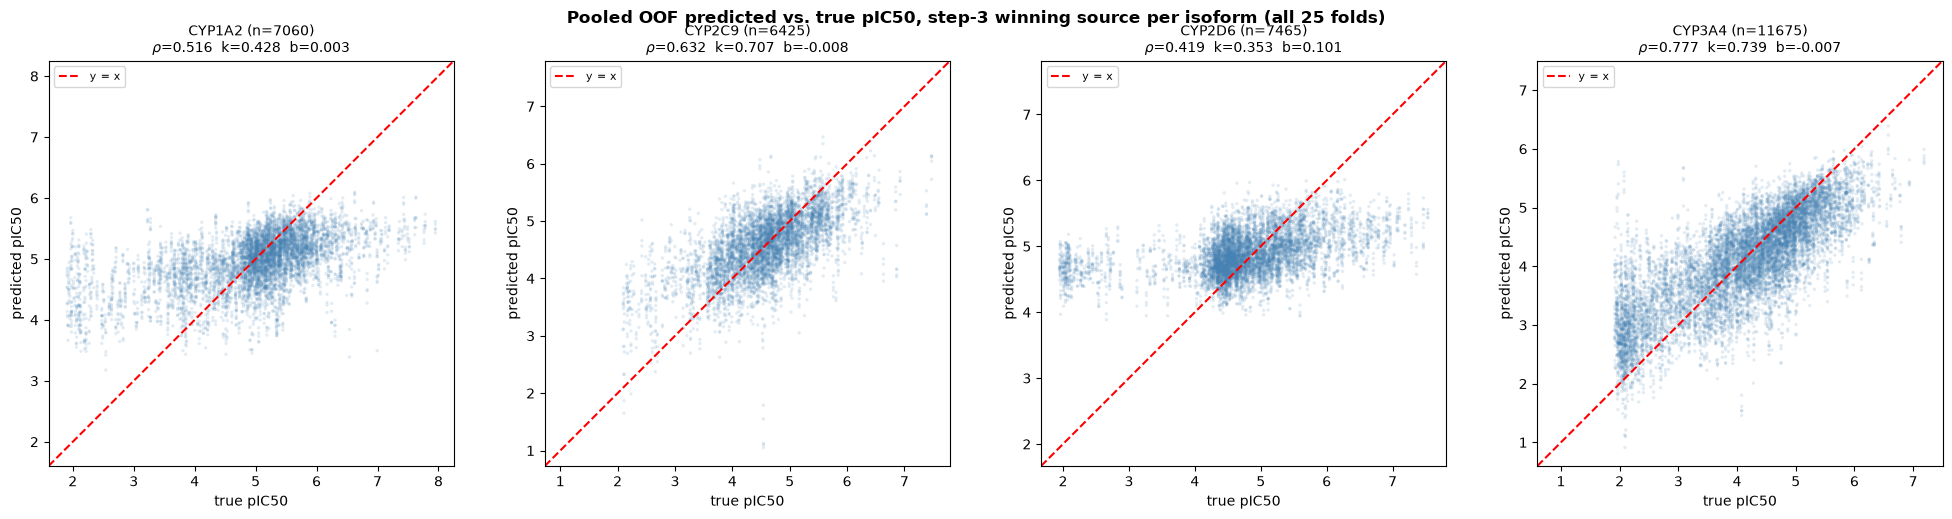

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/09_placement_recalibration/figures/predicted_vs_true_all_isoforms.png


In [5]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, isoform in zip(axes, ISOFORMS):
    y_true, y_pred = pooled_data[isoform]
    ax.scatter(y_true, y_pred, s=6, alpha=0.15, color="steelblue", edgecolors="none")
    lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    pad = 0.05 * (hi - lo)
    lims = (lo - pad, hi + pad)
    ax.plot(lims, lims, "r--", lw=1.5, label="y = x")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect("equal")
    ax.set_xlabel("true pIC50")
    ax.set_ylabel("predicted pIC50")
    row = diagnostic_table.set_index("isoform").loc[isoform]
    ax.set_title(f"{isoform} (n={row['n_pooled']:.0f})\n" + r"$\rho$" + f"={row['rho']:.3f}  k={row['k']:.3f}  b={row['b']:.3f}", fontsize=10)
    ax.legend(loc="upper left", fontsize=8)

fig.suptitle("Pooled OOF predicted vs. true pIC50, step-3 winning source per isoform (all 25 folds)", fontsize=12, fontweight="bold")
plt.tight_layout()
path = FIG_OUT / "predicted_vs_true_all_isoforms.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {path}")

**What this shows:** all four isoforms sit visibly below the y=x line's full
spread -- every point cloud is compressed toward the mean relative to the
diagonal ($k < 1$ for all four: 0.35-0.74), which is the dominant visual
signature of shrinkage/regression-to-the-mean rather than a shift. CYP2D6 is
also visibly the noisiest cloud (lowest $\rho$=0.42, matching its lowest
decomposed R²=0.16) and its OOF predictions sit slightly *above* the diagonal
on average ($b$=0.10, the only isoform with a non-negligible bias term) --
consistent with the table above showing CYP2D6 alone getting a non-trivial
(1.2%) bias contribution to its R² gap. CYP3A4's cloud hugs the diagonal most
closely of the four (highest $\rho$=0.78, highest decomposed R²=0.60), matching
it being this project's best-performing endpoint throughout 05-08.

**Sanity check discussion:** decomposed R² exceeds the observed (05/08
score-file) R² by 0.002-0.010 for every isoform, all comfortably inside the
0.02 tolerance set above. This small, one-directional gap is expected and not
a bug: "observed" R² is the mean of 25 *already-averaged* per-fold bootstrap
estimates (each fold's R² is itself a mean over 1,000 bootstrap resamples of
that fold's ~250-400 compounds, 05/06/07/08's own aggregation convention),
while "decomposed" R² is a single plug-in estimate on the fully pooled,
non-resampled dataset. These are two different, non-identical estimators of a
related quantity (mean-of-per-fold-ratios vs. ratio-of-pooled-sums) and are
not expected to match exactly -- only a *large* divergence would flag an
actual problem. None did.

## Appendix — derivation of $R^2 = 2\rho k - k^2 - b^2$

Applied idea (using this decomposition to triage which isoforms have a
correction-recoverable R² gap vs. a correlation-limited one) per the
SuperCowPowers/`workbench` "placement correction" write-up for this challenge
— **citation pending user confirmation against Zotero**, see the note in the
intro cell above. The algebra itself below is a standard expansion, derived
independently for this notebook, not attributed to that source.

Let $x = y_{\text{true}}$, $y = y_{\text{pred}}$, with means $\bar x, \bar y$;
centered deviations $dx = x - \bar x$, $dy = y - \bar y$; raw bias
$b_{\text{raw}} = \bar y - \bar x$.

1. $R^2 = 1 - SS_{res}/SS_{tot}$, where $SS_{res} = \sum(x-y)^2$ and
   $SS_{tot} = \sum(x - \bar x)^2 = n\sigma_x^2$.
2. $x - y = dx - dy - b_{\text{raw}}$.
3. $\sum(x-y)^2 = \sum dx^2 - 2\sum dx\, dy + \sum dy^2 + n\, b_{\text{raw}}^2$
   (cross terms with $b_{\text{raw}}$ vanish since $\sum dx = \sum dy = 0$).
4. $= n\sigma_x^2 - 2n\rho\sigma_x\sigma_y + n\sigma_y^2 + n\, b_{\text{raw}}^2$
   (using $\sum dx\, dy = n\rho\sigma_x\sigma_y$ by definition of $\rho$).
5. $SS_{res}/SS_{tot} = 1 - 2\rho(\sigma_y/\sigma_x) + (\sigma_y/\sigma_x)^2 + (b_{\text{raw}}/\sigma_x)^2 = 1 - 2\rho k + k^2 + b^2$,
   so $R^2 = 1 - SS_{res}/SS_{tot} = 2\rho k - k^2 - b^2$. $\blacksquare$

This requires $\sigma_x, \sigma_y$ to be the *population* standard deviation
(divide by $n$, `ddof=0`) so that $SS_{tot} = n\sigma_x^2$ exactly — the code
above uses `np.std(..., ddof=0)`, and cell 6's assertion
(`decomposed_r2` vs. direct `sklearn.metrics.r2_score`, matching to 1e-8)
confirms this reproduces the standard R² exactly, not just approximately.

## Section 2 — STOP: pursuit threshold requires user confirmation

**This is a hard stop, not optional — Section 3 (nested-CV validation of a
placement correction) does not begin until the threshold below is confirmed
in writing.**

Restating Section 1's diagnostic table:

| Isoform | Source | n (pooled) | ρ | k | b | Decomposed R² | Observed R² | R² gap from perfect | share from k | share from b | share from ρ |
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| CYP1A2 | ensemble (4-way avg) | 7,060 | 0.516 | 0.428 | 0.003 | 0.258 | 0.254 | 0.742 | 1.0% | 0.0% | 99.0% |
| CYP2C9 | single: chemprop_chemeleoninit (05) | 6,425 | 0.632 | 0.708 | -0.008 | 0.394 | 0.384 | 0.606 | 0.9% | 0.0% | 99.1% |
| CYP2D6 | ensemble (chemeleon__rf + chemprop_chemeleoninit) | 7,465 | 0.419 | 0.353 | 0.101 | 0.161 | 0.156 | 0.839 | 0.5% | 1.2% | 98.3% |
| CYP3A4 | ensemble (chemprop_chemeleoninit + ecfp4_narrow__lightgbm) | 11,675 | 0.776 | 0.739 | -0.007 | 0.602 | 0.599 | 0.398 | 0.4% | 0.0% | 99.6% |

**Headline finding:** for all four isoforms, 98–99.6% of the R² gap from
perfect placement is attributable to $\rho$ (imperfect correlation) — the
$(k-\rho)^2$ (scale) and $b^2$ (bias) terms are each under 1.3% of the gap,
everywhere. A linear placement correction (Section 3 onward) can only ever
close the $(k-\rho)^2$ and $b^2$ portions — it cannot touch the $(1-\rho^2)$
portion, since correlation is invariant to any linear rescale/shift of the
predictions. Under this diagnostic, **the maximum possible R² recovery from a
perfect placement correction is roughly 1-2% of the current R² gap, for every
isoform** — the ceiling is low across the board, not just for some isoforms.

**Needed from the user, in writing, before Section 3 proceeds:**
1. Which isoform(s), if any, are worth pursuing a nested-CV-validated
   placement correction for.
2. The threshold $X$ that justifies pursuit — e.g. "the $(k-\rho)^2 + b^2$
   share of the R² gap is $\geq X$", or any other explicit, quantitative rule
   stated in terms of the columns above. **$X$ is the user's call, not
   Claude's** — nothing above should be read as a recommendation to pick a
   particular $X$, only as the evidence needed to set one.

Given how uniformly small the scale+bias share is here (0.4%-2.2% combined,
every isoform), it is plausible the user's answer is "none of these clear a
reasonable bar" — that is a legitimate outcome of this diagnostic, not a
failure of it.

### Section 2 — threshold confirmed by user

**Threshold $X$ (user's own words, recorded verbatim):** "k+b combined share
of the R² gap must be ≥10% to justify Section 3's nested-CV validation
effort." The user's stated reasoning: this is a **cost-justification**
threshold, not a significance threshold — Section 4's paired test already
handles statistical significance. It asks a different question: even if a
correction significantly improves ST-RAE, is the underlying gap large enough
for the improvement to matter practically, or is it structurally too small to
report as a real lever? 10% is a round, defensible floor: below it, even a
*perfect* correction (fully closing the k+b share) moves R² by less than a
tenth of the total gap — the kind of shift easily lost in fold-to-fold noise.

**Isoforms to pursue:** none — the user selected "skip Section 3 entirely"
after seeing that the max observed k+b share (CYP2D6, 1.7%) sits roughly a
fifth of the 10% bar. Checked programmatically below against the frozen
Section 1 diagnostic table (not re-derived, not hand-typed).

In [6]:
PURSUIT_THRESHOLD_PCT = 10.0  # user-set in Section 2, k+b combined share of the R^2 gap

diagnostic_table["kb_share_pct"] = diagnostic_table["scale_share_pct"] + diagnostic_table["bias_share_pct"]
diagnostic_table["pursued"] = diagnostic_table["kb_share_pct"] >= PURSUIT_THRESHOLD_PCT

print(diagnostic_table[["isoform", "scale_share_pct", "bias_share_pct", "kb_share_pct", "pursued"]].round(2).to_string(index=False))

pursued_isoforms = diagnostic_table.loc[diagnostic_table["pursued"], "isoform"].tolist()
print(f"\nisoforms clearing the {PURSUIT_THRESHOLD_PCT}% threshold: {pursued_isoforms if pursued_isoforms else 'none'}")

isoform  scale_share_pct  bias_share_pct  kb_share_pct  pursued
 CYP1A2             1.05            0.00          1.05    False
 CYP2C9             0.93            0.01          0.94    False
 CYP2D6             0.51            1.21          1.72    False
 CYP3A4             0.36            0.01          0.37    False

isoforms clearing the 10.0% threshold: none


### Formula correction (recorded here, before Section 3, so the notebook's
own history shows this was deliberate)

The original spec for Sections 3/5 sketched the correction as an inverse of
the Section 1 standardization, `(raw - b*sigma_true) / k`. Worked through
algebraically, that sketch is actually the **variance-matching** transform —
`mean_true + (raw - mean_pred) * (sigma_true/sigma_pred)` — which rescales
predictions to match the *target's* variance exactly, with no shrinkage for
imperfect correlation. That is a materially different, more aggressive
transform than an **OLS fit** of true on raw predicted
(`slope, intercept = np.polyfit(y_pred, y_true, deg=1)`): OLS's slope is
$\rho/k$, not $1/k$ — it shrinks by a factor of $\rho$, matching the
well-known regression-to-the-mean property that minimizes squared error. OLS
also has a clean, verifiable closed-form: fit in-sample, the corrected
predictions satisfy $k_{\text{corrected}} = |\rho|$, $b_{\text{corrected}} = 0$,
so by Section 1's own decomposition, $R^2_{\text{corrected}} = 2\rho^2 - \rho^2 = \rho^2$
exactly — a property the variance-matching sketch does not have.

**This notebook now uses OLS wherever a correction formula is needed**
(Sections 3/5 and the frozen-parameters file below) — replacing the original
sketch everywhere it appeared. Section 1's diagnostic $\rho, k, b$ are
unaffected and unchanged: they describe the *raw*, uncorrected R² gap and use
a different parametrization than the correction itself.

**Independent implementation precedent:** verified directly via the GitHub
API (not assumed) — `jeremycheminf/openadmet_scripts`,
[`CYP_Challenge/src/cyp_submission/calibration.py`](https://github.com/jeremycheminf/openadmet_scripts/blob/main/CYP_Challenge/src/cyp_submission/calibration.py),
implements this same OLS transform (`np.polyfit(y_pred, y_true, deg=1)`) for
this same challenge, and its docstring traces the underlying idea to the same
SuperCowPowers/`workbench` write-up cited in this notebook's intro (citation
still pending user confirmation against Zotero — see intro cell).

**Caveat not included above:** a claim was raised that a prior OpenADMET
challenge's `LESSONS_LEARNED.md` documented variance-matching/quantile-mapping
recalibration hurting blind-test performance, with that team submitting raw
predictions instead. This was checked and **could not be verified** —
`jeremycheminf`'s own README describes that document's actual contents as
"Butina scaffold CV, Caruana over NNLS/plain-mean, and several 'tried, didn't
help' leads," with no mention of variance-matching or quantile-mapping, and
the document itself isn't reachable from that repo. It is intentionally
omitted from this notebook as unconfirmed rather than cited as fact.

## Section 3 — nested-CV validation

**Not run for any isoform** — Section 2's confirmed threshold (k+b share ≥10%)
eliminates all four (max 1.7%, CYP2D6). Recorded here for the record, the
formula that *would* have been used, matching the leakage-avoidance pattern
07 established for inner-fold-only tuning:

For each of the 25 (repeat, fold) folds: fit `slope, intercept =
np.polyfit(y_pred, y_true, deg=1)` on the **other 24 folds'** pooled OOF
predictions only (never the held-out fold) — this is the leakage-avoidance
step, analogous to 07's inner-fold-only tuning search. Apply
`corrected = slope * raw_pred + intercept` to the held-out fold's predictions
using those 24-fold-fit parameters, rescore corrected vs. uncorrected through
the same bootstrap/vendor-eval pipeline used throughout, and paired-compare
the 25 fold-level deltas (Shapiro-Wilk → paired t-test if normal, else
Wilcoxon signed-rank — identical method to 06/07/08, no BH/Bonferroni
correction).

## Section 4 — decision rule

**Decision rule (stated for the record, not applied — no isoform reached
Section 3):** adopt the correction for an isoform only if Section 3 shows a
statistically significant improvement in mean ST-RAE across the 25 paired
folds (matching 06/07/08's own governing metric throughout this project,
kept here for consistency rather than switching to R² mid-pipeline). If not
significant, that isoform's raw predictions stand uncorrected — same pattern
as 08's per-isoform decision rule.

## Section 5 — final outcome summary and frozen parameters

No isoform was pursued past Section 2, so no isoform is adopted and no
nested-CV-fit parameters exist to refit on all 25 folds. `slope=1.0,
intercept=0.0` (the identity transform) is written for every isoform below —
deliberately, so the retrain-and-predict step can apply
`corrected = slope * raw_pred + intercept` uniformly to every isoform without
a special-cased branch for "not adopted," and get its raw predictions back
unchanged.

In [7]:
step4_rows = []
for _, row in diagnostic_table.iterrows():
    isoform = row["isoform"]
    step3_row = step3_summary.set_index("isoform").loc[isoform]
    step4_rows.append({
        "isoform": isoform,
        "pursued_past_section2": bool(row["pursued"]),
        "kb_share_pct": row["kb_share_pct"],
        "adopted": False,  # none pursued -> none adopted, this run
        "slope": 1.0,
        "intercept": 0.0,
        "mean_ST-RAE_before": step3_row["winning_mean_ST-RAE"],
        "mean_ST-RAE_after": step3_row["winning_mean_ST-RAE"],  # unchanged: no correction applied
        "mean_R2_before": row["observed_R2"],
        "mean_R2_after": row["observed_R2"],  # unchanged: no correction applied
        "reason": f"k+b share of R^2 gap ({row['kb_share_pct']:.2f}%) below the {PURSUIT_THRESHOLD_PCT:.0f}% Section-2 pursuit threshold",
    })

step4_summary = pd.DataFrame(step4_rows)
print(step4_summary.to_string(index=False))

step4_path = OUT / "step4_summary.csv"
step4_summary.to_csv(step4_path, index=False)
print(f"\nwrote {step4_path}")

recalibration_params = step4_summary[["isoform", "slope", "intercept", "adopted"]]
params_path = OUT / "recalibration_params.csv"
recalibration_params.to_csv(params_path, index=False)
print(f"wrote {params_path}")

isoform  pursued_past_section2  kb_share_pct  adopted  slope  intercept  mean_ST-RAE_before  mean_ST-RAE_after  mean_R2_before  mean_R2_after                                                                 reason
 CYP1A2                  False      1.047113    False    1.0        0.0            0.802210           0.802210        0.253894       0.253894 k+b share of R^2 gap (1.05%) below the 10% Section-2 pursuit threshold
 CYP2C9                  False      0.942309    False    1.0        0.0            0.678691           0.678691        0.383818       0.383818 k+b share of R^2 gap (0.94%) below the 10% Section-2 pursuit threshold
 CYP2D6                  False      1.720178    False    1.0        0.0            0.877152           0.877152        0.155992       0.155992 k+b share of R^2 gap (1.72%) below the 10% Section-2 pursuit threshold
 CYP3A4                  False      0.367814    False    1.0        0.0            0.502901           0.502901        0.599447       0.599447 k+b sh

**What this shows:** every isoform's Roadmap Step 3 winning source (from
`08_ensemble_selection`) stands as-is — CYP1A2's 4-way ensemble average,
CYP2D6's 2-way ensemble average, CYP3A4's 2-way ensemble average, and CYP2C9's
single `chemprop_chemeleoninit` model — with no placement correction applied.
`step4_summary.csv` and `recalibration_params.csv` are written for the
retrain-and-predict step to consume directly: every isoform gets the identity
transform (`slope=1.0, intercept=0.0, adopted=False`), so applying
`corrected = slope * raw_pred + intercept` uniformly reproduces the raw
predictions exactly, with the `reason` column documenting *why* (Section 2's
diagnostic-based pursuit threshold, not a failed significance test — Section 3
was never run) for anyone reading this later without the full notebook
history.